# High-Value Customer Behavior Simulation for a FinTech Subscription Service

## Section S02 — Data Preprocessing

This notebook demonstrates corruption injection and imputation using reusable functions from `src/workflows.py` and `src/processing.py`.


In [1]:
from src.notebook_utils import ensure_project_root_on_path, RAW_DATA, CHECKPOINT_DATA, SYNTHETIC_DIR
ensure_project_root_on_path()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

from src.workflows import create_vip_seed_data, create_corrupted_vip_data, impute_vip_data, summarize_dataset, save_dataset


In [2]:
raw_df = create_vip_seed_data(samples=1000, random_state=42)
corrupted_df = create_corrupted_vip_data(raw_df, missing_proportion=0.2, random_state=42)
save_dataset(corrupted_df, CHECKPOINT_DATA)
corrupted_df.head()


,avg_transaction,frequency,credit_score,vip_status
0,55.66,14.0,737.0,0
1,41.71,11.0,663.0,0
2,63.73,NaN,761.0,0
3,38.31,14.0,NaN,0
4,43.33,14.0,613.0,0


In [3]:
missing_summary = corrupted_df.isna().sum().to_frame('missing_values')
missing_summary


,missing_values
avg_transaction,202
frequency,226
credit_score,209
vip_status,0


In [4]:
imputed_df = impute_vip_data(corrupted_df)
save_dataset(imputed_df, SYNTHETIC_DIR / 'imputed_vip.csv')
summarize_dataset(imputed_df)


,count,mean,std,min,25%,50%,75%,max
avg_transaction,1030.0,52.372280,24.262265,0.0,39.1,49.33,59.548775,264.985
frequency,1030.0,11.894175,3.101688,3.0,10.0,12.00,13.000000,22.000
credit_score,1030.0,714.151456,63.370433,300.0,692.0,715.00,744.000000,850.000
vip_status,1030.0,0.028155,0.165497,0.0,0.0,0.00,0.000000,1.000


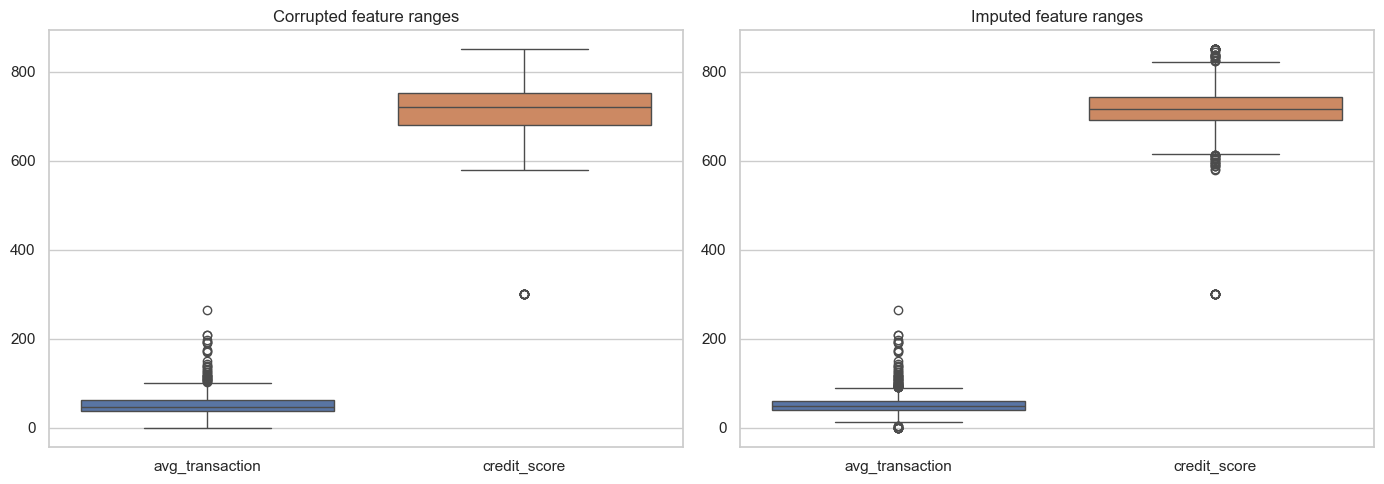

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=corrupted_df[['avg_transaction', 'credit_score']], ax=axes[0])
axes[0].set_title('Corrupted feature ranges')
sns.boxplot(data=imputed_df[['avg_transaction', 'credit_score']], ax=axes[1])
axes[1].set_title('Imputed feature ranges')
plt.tight_layout()
